In [96]:
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'
os.environ['TF_ENABLE_ONEDNN_OPTS'] = '0'

import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization, Conv1D, MaxPooling1D, Flatten
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.utils import to_categorical


In [97]:
cd Raw concatenated

[Errno 2] No such file or directory: 'Raw concatenated'
/home/prasndhdl/Downloads/avatar/Avatar-PrashantD_Forked/prediction_deep_learning/tensorflow


In [100]:
df_raw_backward= pd.read_csv('final_raw_backward.csv')

In [101]:
df_raw_backward['label']=0

In [102]:
df_raw_forward= pd.read_csv('final_raw_forward.csv')

In [103]:
df_raw_forward['label']=1

In [104]:
df_raw_left= pd.read_csv('final_raw_left.csv')

In [105]:
df_raw_left['label']=2

In [106]:
df_raw_right= pd.read_csv('final_raw_right.csv')

In [107]:
df_raw_right['label']=3

In [108]:
df_raw_land= pd.read_csv('final_raw_land.csv')

In [109]:
df_raw_land['label']=4

In [110]:
df_raw_takeoff= pd.read_csv('final_raw_takeoff.csv')

In [112]:
df_raw_takeoff['label']=5

In [113]:
df=pd.concat([df_raw_backward,df_raw_forward,df_raw_left,df_raw_right,df_raw_land,df_raw_takeoff], ignore_index=True)

In [114]:
from sklearn.utils import shuffle


df = shuffle(df, random_state=42)

In [115]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.utils.class_weight import compute_class_weight

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Conv1D, BatchNormalization, MaxPooling1D, Dropout, Flatten, Dense
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.utils import to_categorical

In [116]:
X = df.iloc[:, :-1].copy()
y = df.iloc[:, -1].copy()

# Ensure all feature values are numeric
X = X.apply(pd.to_numeric, errors="coerce")

# Replace inf with NaN, then fill NaN with column medians
X = X.replace([np.inf, -np.inf], np.nan)
X = X.fillna(X.median(numeric_only=True))
X = X.fillna(0.0)

# Ensure labels are integer class ids 0..5
y = pd.to_numeric(y, errors="coerce").fillna(-1).astype(int)
valid_mask = y.between(0, 5)
X = X.loc[valid_mask].reset_index(drop=True)
y = y.loc[valid_mask].reset_index(drop=True)

print("Final X shape:", X.shape)
print("Final y shape:", y.shape)
print("NaN in X:", int(np.isnan(X.values).sum()))
print("Inf in X:", int(np.isinf(X.values).sum()))
print("Class counts:\n", y.value_counts().sort_index())

Final X shape: (2012859, 16)
Final y shape: (2012859,)
NaN in X: 0
Inf in X: 0
Class counts:
 label
0    356535
1    352782
2    375300
3    380304
4    380304
5    167634
Name: count, dtype: int64


In [117]:
#Cell 3: train test split with stratify
X_train_df, X_test_df, y_train_int, y_test_int = train_test_split(
X, y,
test_size=0.2,
random_state=42,
stratify=y
)

In [118]:
#Cell 4: fit scaler on train only, transform both
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_df)
X_test_scaled = scaler.transform(X_test_df)

# Hard stop if anything invalid remains
assert np.isfinite(X_train_scaled).all(), "Non-finite values found in X_train_scaled"
assert np.isfinite(X_test_scaled).all(), "Non-finite values found in X_test_scaled"



In [119]:
#Cell 5: reshape for Conv1D and one-hot encode labels
num_features = X_train_scaled.shape[1] # should be 16
X_train = X_train_scaled.reshape(X_train_scaled.shape[0], num_features, 1)
X_test = X_test_scaled.reshape(X_test_scaled.shape[0], num_features, 1)

y_train = to_categorical(y_train_int, num_classes=6)
y_test = to_categorical(y_test_int, num_classes=6)

print("X_train:", X_train.shape, "X_test:", X_test.shape)
print("y_train:", y_train.shape, "y_test:", y_test.shape)

X_train: (1610287, 16, 1) X_test: (402572, 16, 1)
y_train: (1610287, 6) y_test: (402572, 6)


In [120]:
#Cell 6: class weights for imbalance
classes = np.unique(y_train_int)
class_weights_arr = compute_class_weight(
class_weight="balanced",
classes=classes,
y=y_train_int
)
class_weight_dict = {int(c): float(w) for c, w in zip(classes, class_weights_arr)}
print("Class weights:", class_weight_dict)

Class weights: {0: 0.940935555649048, 1: 0.9509441605899763, 2: 0.8938887778665956, 3: 0.8821276633042229, 4: 0.8821276633042229, 5: 2.0012465170846165}


In [121]:
#Cell 7: stable Conv1D model
tf.keras.backend.clear_session()
tf.random.set_seed(42)
np.random.seed(42)

model = Sequential([
    Input(shape=(num_features, 1)),

    Conv1D(32, kernel_size=3, activation="relu", padding="same"),
    BatchNormalization(),
    MaxPooling1D(pool_size=2),

    Conv1D(64, kernel_size=3, activation="relu", padding="same"),
    BatchNormalization(),
    MaxPooling1D(pool_size=2),

    Flatten(),
    Dense(128, activation="relu"),
    Dropout(0.4),
    Dense(6, activation="softmax")
])

In [122]:
#Cell 8: stable compile
optimizer = Adam(learning_rate=1e-4, clipnorm=1.0)
model.compile(
optimizer=optimizer,
loss=tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.05),
metrics=["accuracy"]
)
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 16, 32)         │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 16, 32)         │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 8, 32)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 8, 64)          │         6,208 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 8, 64)          │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_1 (MaxPooling1D)  │ (None, 4, 64)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 40,390 (157.77 KB)

 Trainable params: 40,198 (157.02 KB)

 Non-trainable params: 192 (768.00 B)

In [123]:
#Cell 9: callbacks and fit
early_stopping = EarlyStopping(
monitor="val_loss",
patience=10,
verbose=1,
restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=4,
    min_lr=1e-6,
    verbose=1
)

history = model.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=80,
    batch_size=128,
    callbacks=[early_stopping, reduce_lr],
    class_weight=class_weight_dict,
    verbose=1
)

Epoch 1/80
12581/12581 ━━━━━━━━━━━━━━━━━━━━ 31s 2ms/step - accuracy: 0.8070 - loss: 0.6994 - val_accuracy: 0.9810 - val_loss: 0.3854 - learning_rate: 1.0000e-04
Epoch 2/80
12581/12581 ━━━━━━━━━━━━━━━━━━━━ 29s 2ms/step - accuracy: 0.9511 - loss: 0.4266 - val_accuracy: 0.9885 - val_loss: 0.3265 - learning_rate: 1.0000e-04
Epoch 3/80
12581/12581 ━━━━━━━━━━━━━━━━━━━━ 30s 2ms/step - accuracy: 0.9693 - loss: 0.3825 - val_accuracy: 0.9903 - val_loss: 0.3076 - learning_rate: 1.0000e-04
Epoch 4/80
12581/12581 ━━━━━━━━━━━━━━━━━━━━ 30s 2ms/step - accuracy: 0.9764 - loss: 0.3625 - val_accuracy: 0.9923 - val_loss: 0.2975 - learning_rate: 1.0000e-04
Epoch 5/80
12581/12581 ━━━━━━━━━━━━━━━━━━━━ 30s 2ms/step - accuracy: 0.9799 - loss: 0.3510 - val_accuracy: 0.9934 - val_loss: 0.2918 - learning_rate: 1.0000e-04
Epoch 6/80
12581/12581 ━━━━━━━━━━━━━━━━━━━━ 29s 2ms/step - accuracy: 0.9823 - loss: 0.3431 - val_accuracy: 0.9925 - val_loss: 0.2895 - learning_rate: 1.0000e-04
Epoch 7/80
12581/12581 ━━━━━━━━━━━

In [124]:
#Cell 10: quick sanity evaluation
test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)
print("Test loss:", test_loss)
print("Test accuracy:", test_acc)



Test loss: 0.2626778185367584
Test accuracy: 0.9953722357749939


In [125]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2012859 entries, 1966437 to 121958
Data columns (total 17 columns):
 #   Column          Dtype  
---  ------          -----  
 0   EXG Channel 0   float64
 1   EXG Channel 1   float64
 2   EXG Channel 2   float64
 3   EXG Channel 3   float64
 4   EXG Channel 4   float64
 5   EXG Channel 5   float64
 6   EXG Channel 6   float64
 7   EXG Channel 7   float64
 8   EXG Channel 8   float64
 9   EXG Channel 9   float64
 10  EXG Channel 10  float64
 11  EXG Channel 11  float64
 12  EXG Channel 12  float64
 13  EXG Channel 13  float64
 14  EXG Channel 14  float64
 15  EXG Channel 15  float64
 16  label           int64  
dtypes: float64(16), int64(1)
memory usage: 276.4 MB


In [126]:
df.tail()

,EXG Channel 0,EXG Channel 1,EXG Channel 2,EXG Channel 3,EXG Channel 4,EXG Channel 5,EXG Channel 6,EXG Channel 7,EXG Channel 8,EXG Channel 9,EXG Channel 10,EXG Channel 11,EXG Channel 12,EXG Channel 13,EXG Channel 14,EXG Channel 15,label
259178,-15990.415632,-37122.045412,-40281.419788,-10000.125766,-17996.641159,-11252.739877,-25093.230616,-32585.982393,-6709.904279,-16080.068479,-13272.890541,-5.834297e+03,-24728.316036,-17698.133611,-187500.022352,-35782.125387,0
1414414,555.664367,1616.031124,-20565.840073,-10537.506406,-19107.344044,-187500.022352,-22352.482063,1625.262395,-5977.795241,-13558.322317,-26884.521769,1.875000e+05,-16479.315338,-187500.022352,-18092.910122,-28260.003419,3
131932,-65856.129331,-47485.722302,-70968.643840,-68037.436073,-74234.792499,-59864.364250,-71196.139895,-59159.837265,-36253.255457,-54692.505859,-68433.285467,2.445994e+06,-64900.212276,-69016.889515,-58147.102075,-14471.726355,0
671155,-41136.485772,-51637.245910,-187500.022352,-57209.401692,-64979.650376,-61073.235997,-72251.544565,-54300.188041,-34000.669003,-54175.308844,-187500.022352,-5.567721e+04,-65117.113604,-65947.682076,-72018.170001,-187500.022352,1
121958,13166.943272,14823.632219,-13755.442352,-9871.089145,-16649.836797,17722.117033,-33694.740676,13575.264940,24229.536859,11977.316377,-3092.229735,3.871874e+04,-17929.362408,-822.007754,45223.368135,32788.489197,0


In [127]:
# Convert labels to one-hot encoding for multi-class classification
y_train = to_categorical(y_train, num_classes=6)
y_test = to_categorical(y_test, num_classes=6)

In [128]:
# Compile the model
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

In [129]:
model.save('EEG_model.h5')

In [130]:
from keras.models import load_model

# Load the model from the file
model = load_model('EEG_model.h5')

In [131]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 16, 32)         │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 16, 32)         │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 8, 32)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 8, 64)          │         6,208 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 8, 64)          │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_1 (MaxPooling1D)  │ (None, 4, 64)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 40,392 (157.79 KB)

 Trainable params: 40,198 (157.02 KB)

 Non-trainable params: 192 (768.00 B)

 Optimizer params: 2 (12.00 B)

In [132]:
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix

# Predict the classes with the model
predictions = model.predict(X_test)
predicted_classes = np.argmax(predictions, axis=1)
true_classes = np.argmax(y_test, axis=1)

12581/12581 ━━━━━━━━━━━━━━━━━━━━ 8s 665us/step


In [134]:
# Diagnose current label shapes
print("y_test shape:", np.shape(y_test))
print("predictions shape:", np.shape(predictions))

# Build 1D true classes robustly
if hasattr(y_test_int, "to_numpy"):
    true_classes = y_test_int.to_numpy()   # safest in your current notebook
else:
    true_classes = np.argmax(y_test, axis=-1) if np.ndim(y_test) > 1 else y_test

# Build 1D predicted classes
predicted_classes = np.argmax(predictions, axis=1)

print("true_classes shape:", true_classes.shape)
print("predicted_classes shape:", predicted_classes.shape)

accuracy = accuracy_score(true_classes, predicted_classes)
print(f"Accuracy: {accuracy * 100:.2f}%")

y_test shape: (402572, 6, 6)
predictions shape: (402572, 6)
true_classes shape: (402572,)
predicted_classes shape: (402572,)
Accuracy: 99.54%


In [135]:
report = classification_report(true_classes, predicted_classes, target_names=['Backward', 'Forward', 'Left', 'Right', 'Land', 'Takeoff'])
print("Classification Report:\n", report)


Classification Report:
               precision    recall  f1-score   support

    Backward       0.99      0.99      0.99     71307
     Forward       0.99      0.99      0.99     70556
        Left       1.00      0.99      1.00     75060
       Right       1.00      1.00      1.00     76061
        Land       1.00      1.00      1.00     76061
     Takeoff       0.99      0.99      0.99     33527

    accuracy                           1.00    402572
   macro avg       1.00      1.00      1.00    402572
weighted avg       1.00      1.00      1.00    402572



In [136]:
from sklearn.metrics import confusion_matrix
import pandas as pd

conf_matrix = confusion_matrix(true_classes, predicted_classes)


conf_matrix_df = pd.DataFrame(conf_matrix,
                              index=['Backward', 'Forward', 'Left', 'Right', 'Land', 'Takeoff'], 
                              columns=['Backward', 'Forward', 'Left', 'Right', 'Land', 'Takeoff'])

print("Confusion Matrix:")
print(conf_matrix_df)

Confusion Matrix:
          Backward  Forward   Left  Right   Land  Takeoff
Backward     70903      279     85     10     27        3
Forward        311    70057     13      7      7      161
Left            50       20  74653     95    241        1
Right            5       17     85  75854     84       16
Land            13       30      7     81  75925        5
Takeoff          3      183     10     13      1    33317


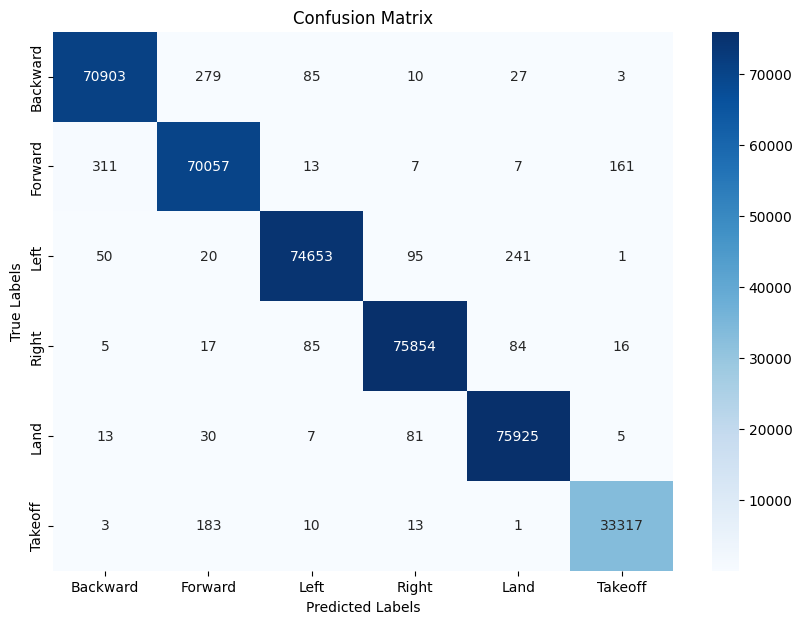

In [137]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,7))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=['Backward', 'Forward', 'Left', 'Right', 'Land', 'Takeoff'], yticklabels=['Backward', 'Forward', 'Left', 'Right', 'Land', 'Takeoff'])
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Confusion Matrix')
plt.savefig('ConfusionMatrix.png')
plt.show()
